# Running Palace Simulations

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a spiral inductor with Metal1 guard ring, and fitting the resulting S-parameters to an RLC equivalent circuit model for use in [circulax](https://github.com/gdsfactory/circulax).

**Requirements:**
- IHP PDK: `uv pip install ihp-gdsfactory`
- gsim with Palace backend
- circulax: `pip install circulax`

### Build inductor + guard ring

**Known PDK limitation:** `gf.components.inductor` accepts a `turns` parameter but does not use it in geometry construction. The spiral is always single-turn regardless of the value passed.


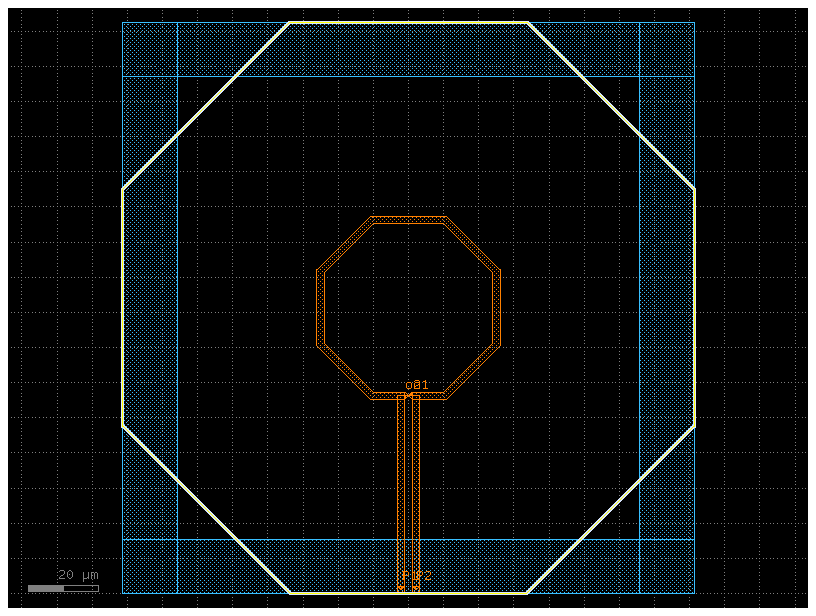

In [1]:
import gdsfactory as gf
from ihp import PDK

PDK.activate()

c = gf.components.inductor(
    width=2,
    space=2.1,
    diameter=50,
    turns=1,
    layer_metal="TopMetal2drawing",
    layer_inductor="INDdrawing",
    layer_metal_pin="TopMetal2drawing",
    layers_no_fill=("NoMetFillerdrawing",),
).copy()

# Define guard ring dimensions based on the inductor's bounding box
bbox = c.bbox()
xmin, ymin = bbox.left, bbox.bottom
xmax, ymax = bbox.right, bbox.top

margin_outer = 0.0
margin_inner = -15.0

xlo, xro = xmin - margin_outer, xmax + margin_outer
ybo, yto = ymin - margin_outer, ymax + margin_outer
xli, xri = xmin - margin_inner, xmax + margin_inner
ybi, yti = ymin - margin_inner, ymax + margin_inner

w_v = xli - xlo  # Width vertical walls
h_h = yto - yti  # Height horizontal walls
over = 0.5  # Overlap for Gmsh to fuse the pieces

# Left wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + over, yto - ybo), layer="Metal1drawing", centered=True
    )
).move((xlo + w_v / 2 + over / 2, (yto + ybo) / 2))
# Right wall
c.add_ref(
    gf.components.rectangle(
        size=(w_v + over, yto - ybo), layer="Metal1drawing", centered=True
    )
).move((xro - w_v / 2 - over / 2, (yto + ybo) / 2))
# Top wall
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + over), layer="Metal1drawing", centered=True
    )
).move(((xro + xlo) / 2, yto - h_h / 2 - over / 2))
# Bottom wall
c.add_ref(
    gf.components.rectangle(
        size=(xro - xlo, h_h + over), layer="Metal1drawing", centered=True
    )
).move(((xro + xlo) / 2, ybo + h_h / 2 + over / 2))

cc = c.copy()

c.draw_ports()
c.plot()

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-inductor-guardring")

# Set the component geometry
sim.set_geometry(cc)

# Configure layer stack from active PDK
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# Configure ports
sim.add_port(
    "P1", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True
)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=10e9, fmax=200e9, num_points=50)

# Validate configuration
print(sim.validate_config())

Validation: PASSED


In [3]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=1.5)

Small conductor feature detected (2.100 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Mesh Summary
Dimensions: 362.6 x 362.6 x 251.3 µm
Nodes:      10,850
Elements:   83,869
Tetrahedra: 62,147
Edge length: 0.40 - 256.40 µm
Quality:    0.537 (min: 0.003)
SICN:       0.579 (all valid)
----------------------------------------
Volumes (4):
  - silicon [1]
  - SiO2 [2]
  - passive [3]
  - air [4]
Surfaces (12):
  - metal1_xy [5]
  - metal1_z [6]
  - topmetal2_xy [7]
  - topmetal2_z [8]
  - P1 [9]
  - P2 [10]
  - air__silicon [11]
  - SiO2__silicon [12]
  - SiO2__air [13]
  - SiO2__passive [14]
  - air__passive [15]
  - air__None [16]
----------------------------------------
Mesh:   palace-sim-inductor-guardring/palace.msh

In [4]:
sim.plot_mesh(show_groups=["metal", "P"])

Widget(value='<iframe src="http://localhost:33553/index.html?ui=P_0x72130414fd70_0&reconnect=auto" class="pyvi…

In [5]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "sio2__None", "air__sio2"],
)

Widget(value='<iframe src="http://localhost:33553/index.html?ui=P_0x7211f82aa930_1&reconnect=auto" class="pyvi…

### Run simulation on cloud

In [6]:
# Run simulation on GDSFactory+ cloud
results = sim.run(parent_dir="./palace-sim-inductor-guardring")

  palace-23c82a75  completed  2m 24s
Extracting results.tar.gz...
Downloaded 11 files to palace-sim-inductor-guardring/sim-data-palace-23c82a75


In [7]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2


In [8]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2


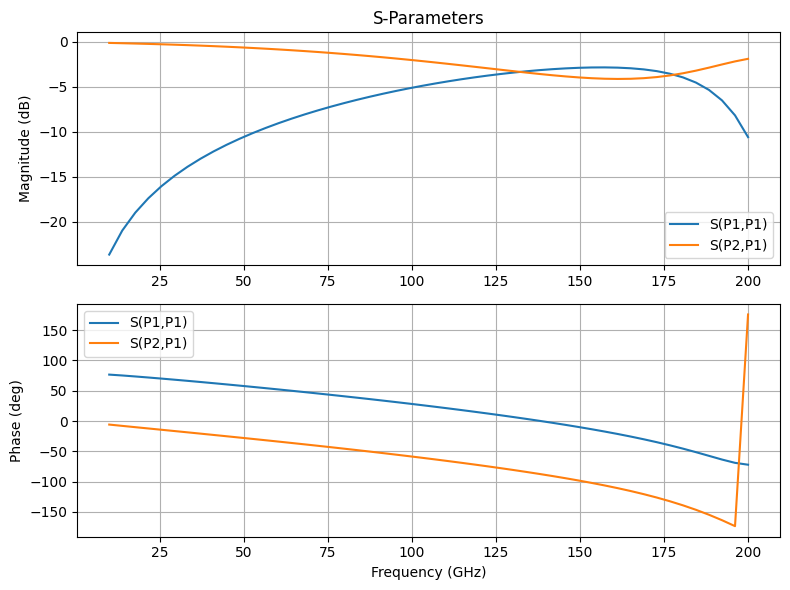

In [9]:
results.plot()

### Analytical RLC Model Fit

### Extract Differential Impedance

We assemble the S-parameter matrix from the simulation results into a scikit-rf `Network` object, which handles the conversion to Z-parameters. From the 2×2 Z-matrix we compute the differential impedance $Z_\text{diff} = Z_{11} - Z_{12} - Z_{21} + Z_{22}$, which is the impedance seen between the two ports of the inductor under differential excitation.

In [10]:
import numpy as np
import skrf as rf

f = results.freq * 1e9  # GHz → Hz
w = 2 * np.pi * f

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit="hz")
Z = ntwk.z

Z_sim = Z[:, 0, 0] - Z[:, 0, 1] - Z[:, 1, 0] + Z[:, 1, 1]
f_sim = f

### RLC Model Definition

We fit an RLC equivalent circuit model to the simulated impedance data. The inductor is modeled as a series RL branch in parallel with a parasitic capacitance C:

![RLC circuit](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ0uNKKpZW2GvEA-o6wyoEceo8uNf8vipsj4AJEbG2j_r7awmb0TyKeWyYU&s=10)

The total impedance is:

$$Z(f) = \frac{1}{j2\pi f C + \frac{1}{R + j2\pi f L}}$$

We define the RLC impedance as a function of frequency. The total admittance (inverse of impedance) is the sum of the admittance of the series RL branch and the parasitic capacitance:

$$\frac{1}{Z(f)} = \frac{1}{R + j2\pi f L} + j2\pi f C$$

We rewrite the RLC impedance in normalized form. Defining $\tilde\omega = \omega/\omega_0$, the dimensionless impedance is:

$$z(\tilde\omega, Q) = \frac{1 + j\tilde\omega Q}{1 - \tilde\omega^2 + j\tilde\omega/Q}$$

so that $Z(f) = R \cdot z(f/f_0, Q)$.

The loss function measures the total squared error between the model and the simulated data across all frequencies:

$$\mathcal{L}(f_0, Q, R) = \sum_k \left| Z_\text{sim}(f_k) - R \cdot z(f_k/f_0, Q) \right|^2$$

This is a real-valued scalar that JAX will differentiate with respect to $f_0$, $Q$, and $R$ to drive the optimization.

In [11]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)


# The RLC impedance function.
def z_rlc(w, Q):
    return (1 + 1j * w * Q) / (1 - w**2 + 1j * w / Q)


f_jnp = jnp.array(f_sim, dtype=jnp.float64)
Z_target = jnp.array(Z_sim, dtype=jnp.complex128)


@jax.jit
def loss_fn(param):
    z_fit = param[2] * z_rlc(f_jnp / param[0], param[1])
    z_err = Z_target - z_fit
    return jnp.real(jnp.sum(z_err * jnp.conj(z_err)))

### Initial Parameter Estimation

We estimate the initial values of $R$, $L$, and $C$ directly from the data before running the optimization. Good initial values help the optimizer converge faster and avoid local minima.

- $f_0$ is read from the frequency at which $|Z|$ is maximum
- $R \approx \text{Re}(Z)|_{f \to 0}$, the low-frequency resistance
- $Q$ is estimated from the -3 dB bandwidth: $Q = f_0 / \Delta f$, where $\Delta f$ is the width of the peak above $|Z|_\text{max}/\sqrt{2}$

In [12]:
absZ = np.abs(Z_sim)
f0_ini = float(f_sim[np.argmax(absZ)])
R_ini = float(Z_sim.real[0])
mask = absZ > np.max(absZ) / np.sqrt(2)
Q_ini = f0_ini / np.ptp(f_sim[mask]) if mask.sum() > 1 else 5.0
par_ini = jnp.array([f0_ini, Q_ini, R_ini])

print(f"f0 = {f0_ini / 1e9:.3f} GHz | Q = {Q_ini:.3f} | R = {R_ini:.4f} Ω")

f0 = 180.612 GHz | Q = 5.000 | R = 0.9723 Ω


### Optimization

We minimize the squared error between the model and the data over all frequencies using the Adam optimizer.

At each step, Adam computes the gradient $\nabla_\theta \mathcal{L}$ automatically via JAX autodiff and updates the parameters:

$$\theta_{n+1} = \theta_n - \alpha \cdot \text{Adam}(\nabla_\theta \mathcal{L}(\theta_n))$$

In [13]:
import optax

optimizer = optax.adam(learning_rate=0.05)
opt_state = optimizer.init(par_ini)
vg_fn = jax.jit(jax.value_and_grad(loss_fn))
vg_fn(par_ini)

par = par_ini
for step in range(1000):
    loss, grads = vg_fn(par)
    if step % 200 == 0:
        print(
            f"step {step:4d}: f0={float(par[0]) / 1e9:.4f} GHz  Q={float(par[1]):.3f}  R={float(par[2]):.4f}  loss={float(loss):.3e}"
        )
    updates, opt_state = optimizer.update(grads, opt_state)
    par = optax.apply_updates(par, updates)

f0_fit, Q_fit, R_fit = float(par[0]), float(par[1]), float(par[2])

step    0: f0=180.6122 GHz  Q=5.000  R=0.9723  loss=3.361e+07
step  200: f0=180.6122 GHz  Q=16.433  R=10.4974  loss=4.486e+06
step  400: f0=180.6122 GHz  Q=19.005  R=8.4184  loss=3.288e+06
step  600: f0=180.6122 GHz  Q=21.759  R=6.8305  loss=2.439e+06
step  800: f0=180.6122 GHz  Q=24.122  R=5.8334  loss=1.985e+06


### Recover L and C

Once converged, $L$ and $C$ are recovered analytically from the fitted $(f_0, Q, R)$ using the RLC resonance relations:

$$L = \frac{Q \cdot R}{\omega_0}, \quad C = \frac{1}{L\omega_0^2}$$

where $\omega_0 = 2\pi f_0$.

In [14]:
w0 = 2 * np.pi * f0_fit
tau = Q_fit / w0
L_fit = tau * R_fit
C_fit = 1 / (L_fit * w0**2)

print(f"R = {R_fit:.6f} Ω")
print(f"L = {L_fit * 1e12:.4f} pH")
print(f"C = {C_fit * 1e15:.4f} fF")
print(f"f0 = {f0_fit / 1e9:.4f} GHz  Q = {Q_fit:.3f}")

R = 5.213687 Ω
L = 119.2287 pH
C = 6.5128 fF
f0 = 180.6122 GHz  Q = 25.952


### Results

We evaluate the fitted model across the full frequency range and compare it against the simulation data. The two plots show the magnitude $|Z(f)|$ on a log scale and the phase $\arg(Z(f))$ in degrees — a good fit should reproduce both the inductive rise, the resonance peak, and the phase transition.


R = 5.213687 Ω
L = 119.2287 pH
C = 6.5128 fF
f0 = 180.6122 GHz  Q = 25.952


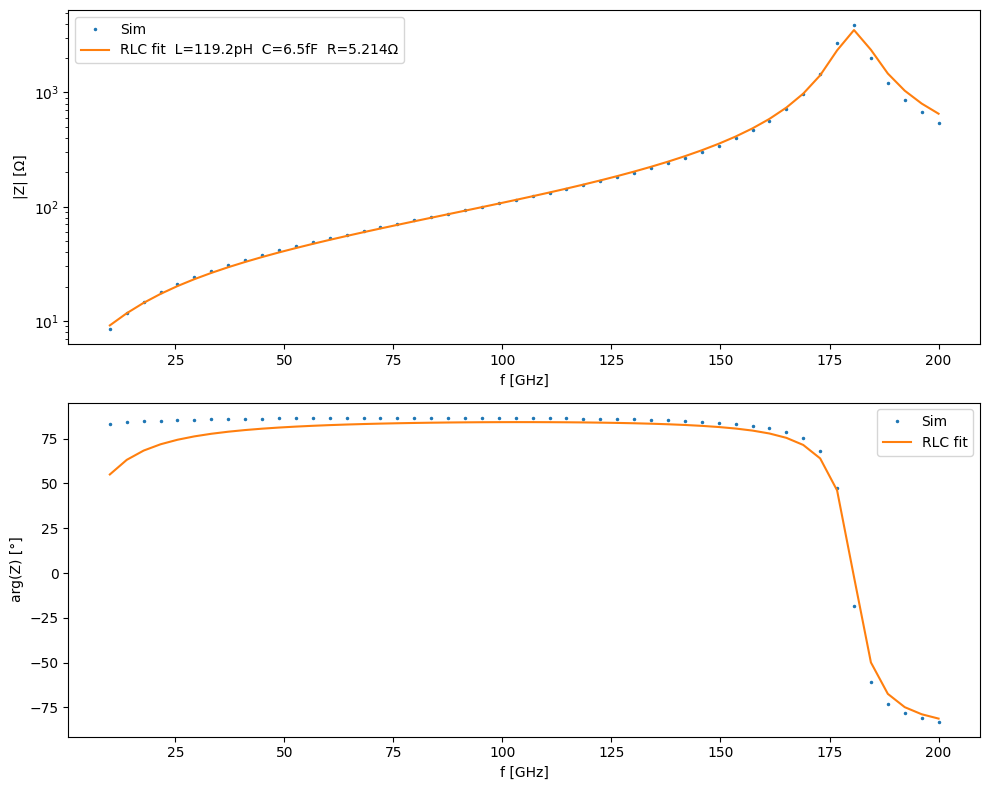

In [15]:
import matplotlib.pyplot as plt

print(f"\nR = {R_fit:.6f} Ω")
print(f"L = {L_fit * 1e12:.4f} pH")
print(f"C = {C_fit * 1e15:.4f} fF")
print(f"f0 = {f0_fit / 1e9:.4f} GHz  Q = {Q_fit:.3f}")

Z_fit = np.array([R_fit * z_rlc(f / f0_fit, Q_fit) for f in f_sim])

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(f_sim / 1e9, np.abs(Z_sim), ".", ms=3, label="Sim")
axes[0].plot(
    f_sim / 1e9,
    np.abs(Z_fit),
    label=f"RLC fit  L={L_fit * 1e12:.1f}pH  C={C_fit * 1e15:.1f}fF  R={R_fit:.3f}Ω",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("f [GHz]")
axes[0].set_ylabel("|Z| [Ω]")
axes[0].legend()

axes[1].plot(f_sim / 1e9, np.angle(Z_sim, deg=True), ".", ms=3, label="Sim")
axes[1].plot(f_sim / 1e9, np.angle(Z_fit, deg=True), label="RLC fit")
axes[1].set_xlabel("f [GHz]")
axes[1].set_ylabel("arg(Z) [°]")
axes[1].legend()
plt.tight_layout()
plt.show()

### Circulax-Based Inverse Design

### Define Circulax Component

With the fitted values from the analytical fit, we define `my_inductor` as a frequency-domain circulax component using `@fdomain_component`. The decorator converts the RLC admittance matrix into a two-port component compatible with any circulax netlist.

The admittance matrix for a symmetric two-port is:

$$Y = \begin{pmatrix} Y_\text{tot} & -Y_\text{tot} \\ -Y_\text{tot} & Y_\text{tot} \end{pmatrix}, \quad Y_\text{tot} = \frac{1}{R + j2\pi f L} + j2\pi f C$$

The netlist connects the inductor directly between `IN` and `GND` — a single-port measurement configuration, consistent with how $Z_\text{diff}$ was extracted from the simulation.

In [16]:
from circulax import compile_circuit
from circulax.s_transforms import fdomain_component

# Equivalent circuit:
#
#         --- C ---
#        |         |
# p1 ----+---R--L--+---- p2


@fdomain_component(ports=("p1", "p2"))
def my_inductor(f, R=1.0, L=100e-12, C=10e-15):
    w = 2.0 * jnp.pi * f
    Y_RL = 1.0 / (R + 1j * w * L)  # series RL branch
    Y_C = 1j * w * C  # parallel capacitance
    Y = Y_RL + Y_C
    return jnp.array([[Y, -Y], [-Y, Y]], dtype=jnp.complex128)


net_dict = {
    "instances": {
        "GND": {"component": "ground"},
        "L1": {
            "component": "my_inductor",
            "settings": {"R": R_fit, "L": L_fit, "C": C_fit},
        },
    },
    "connections": {
        "L1,p1": "IN",
        "L1,p2": "GND,p1",
    },
}

models = {"my_inductor": my_inductor, "ground": lambda: 0}

circuit = compile_circuit(net_dict, models)
groups = circuit.groups
freqs = jnp.asarray(f_sim)
Z_target = jnp.asarray(Z_sim)

print("Circuit compiled. System size:", circuit.sys_size)
print("Port map:", circuit.port_map)

Circuit compiled. System size: 2
Port map: {'GND,p1': 0, 'L1,p2': 0, 'IN': 1, 'L1,p1': 1}


### Inverse Design with Circulax

We use `circulax` inside the optimization loop as part of a differentiable **inverse design** workflow. At each step, we perform a full AC sweep and minimize the discrepancy between the compact-model impedance and the Palace simulation data:

$$
\mathcal{L}(R,L,C)
=
\sum_k
\left|
Z_{\mathrm{target}}(f_k)
-
z_0
\frac{
1 + S_{11}(f_k)
}{
1 - S_{11}(f_k)
}
\right|^2
$$

where the impedance is recovered from the simulated reflection coefficient through the standard one-port relation

$$
Z(f)
=
z_0
\frac{
1 + S_{11}(f)
}{
1 - S_{11}(f)
}.
$$

The optimization is initialized using the analytical RLC fit parameters. To ensure physically meaningful values throughout the optimization, we optimize unconstrained variables and map them to positive parameters using a softplus parameterization:

$$
R,L,C > 0.
$$

This enables stable gradient-based optimization using JAX automatic differentiation and Optax optimizers.

In [17]:
from circulax.solvers import setup_ac_sweep
from circulax.utils import update_params_dict

# Port node for IN — check port_map output above
port_node = next(v for k, v in circuit.port_map.items() if k == "IN")


# Positive parametrization
# raw_params -> softplus -> positive physical parameters
def positive(x):
    return jax.nn.softplus(x)


# inverse-softplus
def inv_softplus(y):
    return jnp.log(jnp.exp(y) - 1.0)


def loss_circulax(raw_params):
    params = positive(raw_params)
    R, L, C = params
    g = update_params_dict(groups, "my_inductor", "L1", "R", R)
    g = update_params_dict(g, "my_inductor", "L1", "L", L)
    g = update_params_dict(g, "my_inductor", "L1", "C", C)

    y_op = circuit.with_groups(g)()
    ac = setup_ac_sweep(groups=g, num_vars=circuit.sys_size, port_nodes=[port_node])
    sol = ac(freqs=freqs, y_dc=y_op)

    S11 = sol[:, 0, 0]
    Z_cx = 50.0 * (1 + S11) / (1 - S11)
    err_re = jnp.real(Z_cx) - jnp.real(Z_target)
    err_im = jnp.imag(Z_cx) - jnp.imag(Z_target)
    loss = jnp.mean(err_re**2 + err_im**2)

    return loss


raw_params_ini = inv_softplus(
    jnp.array(
        [
            R_fit,
            L_fit,
            C_fit,
        ]
    )
)

optimizer = optax.adam(1e-2)
opt_state = optimizer.init(raw_params_ini)
vg_fn = jax.jit(jax.value_and_grad(loss_circulax))
vg_fn(raw_params_ini)  # warm-up

raw_params = raw_params_ini
for step in range(500):
    loss, grads = vg_fn(raw_params)
    if step % 20 == 0:
        params = positive(raw_params)
        R_, L_, C_ = params
        print(
            f"step {step:3d}: R={float(R_):.5f} Ω  L={float(L_) * 1e12:.3f} pH  C={float(C_) * 1e15:.3f} fF  loss={float(loss):.3e}"
        )
    updates, opt_state = optimizer.update(grads, opt_state)
    raw_params = optax.apply_updates(raw_params, updates)

R_fit_cx, L_fit_cx, C_fit_cx = [float(x) for x in positive(raw_params)]
f0_cx = 1.0 / (2 * np.pi * np.sqrt(L_fit_cx * C_fit_cx))
Q_cx = 2 * np.pi * f0_cx * L_fit_cx / R_fit_cx

print(f"\nR = {R_fit_cx:.6f} Ω")
print(f"L = {L_fit_cx * 1e12:.4f} pH")
print(f"C = {C_fit_cx * 1e15:.4f} fF")
print(f"f0 = {f0_cx / 1e9:.4f} GHz  Q = {Q_cx:.3f}")

step   0: R=5.21369 Ω  L=119.229 pH  C=6.439 fF  loss=1.286e+05
step  20: R=5.11440 Ω  L=120.277 pH  C=6.489 fF  loss=1.366e+04
step  40: R=4.92842 Ω  L=120.582 pH  C=6.487 fF  loss=7.306e+03
step  60: R=4.77188 Ω  L=120.778 pH  C=6.489 fF  loss=4.960e+03
step  80: R=4.66907 Ω  L=120.666 pH  C=6.494 fF  loss=4.508e+03
step 100: R=4.61290 Ω  L=120.409 pH  C=6.509 fF  loss=4.279e+03
step 120: R=4.57989 Ω  L=120.050 pH  C=6.528 fF  loss=4.052e+03
step 140: R=4.55112 Ω  L=119.658 pH  C=6.549 fF  loss=3.820e+03
step 160: R=4.51983 Ω  L=119.253 pH  C=6.571 fF  loss=3.586e+03
step 180: R=4.48636 Ω  L=118.839 pH  C=6.594 fF  loss=3.351e+03
step 200: R=4.45214 Ω  L=118.416 pH  C=6.618 fF  loss=3.120e+03
step 220: R=4.41777 Ω  L=117.986 pH  C=6.642 fF  loss=2.894e+03
step 240: R=4.38341 Ω  L=117.553 pH  C=6.666 fF  loss=2.676e+03
step 260: R=4.34918 Ω  L=117.120 pH  C=6.691 fF  loss=2.466e+03
step 280: R=4.31528 Ω  L=116.688 pH  C=6.716 fF  loss=2.265e+03
step 300: R=4.28186 Ω  L=116.259 pH  C=6

### Results

We compare the analytical fit and the circulax inverse design against the original simulation data.

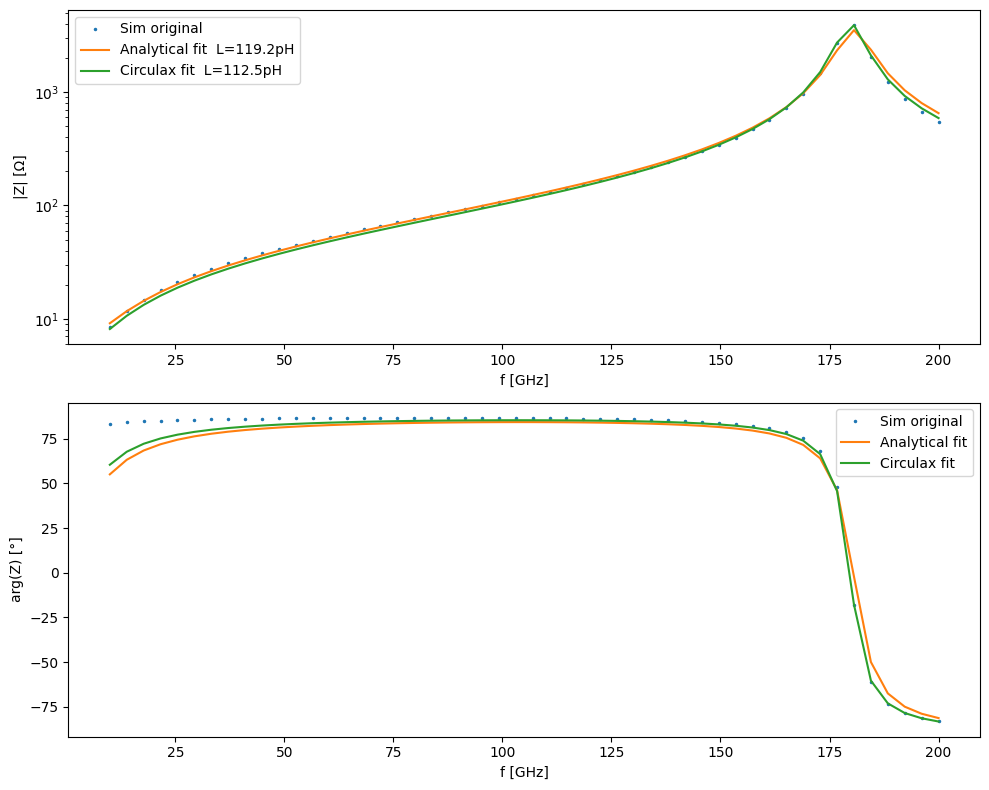

In [18]:
g_final = update_params_dict(groups, "my_inductor", "L1", "R", R_fit_cx)
g_final = update_params_dict(g_final, "my_inductor", "L1", "L", L_fit_cx)
g_final = update_params_dict(g_final, "my_inductor", "L1", "C", C_fit_cx)

y_op_final = circuit.with_groups(g_final)()
ac_final = setup_ac_sweep(
    groups=g_final, num_vars=circuit.sys_size, port_nodes=[port_node]
)
sol_final = ac_final(freqs=freqs, y_dc=y_op_final)

S11_final = sol_final[:, 0, 0]
Z_cx_final = 50.0 * (1 + S11_final) / (1 - S11_final)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
axes[0].plot(f_sim / 1e9, np.abs(Z_sim), ".", ms=3, label="Sim original")
axes[0].plot(
    f_sim / 1e9, np.abs(Z_fit), label=f"Analytical fit  L={L_fit * 1e12:.1f}pH"
)
axes[0].plot(
    f_sim / 1e9, np.abs(Z_cx_final), label=f"Circulax fit  L={L_fit_cx * 1e12:.1f}pH"
)
axes[0].set_yscale("log")
axes[0].set_xlabel("f [GHz]")
axes[0].set_ylabel("|Z| [Ω]")
axes[0].legend()

axes[1].plot(
    f_sim / 1e9, np.angle(np.array(Z_sim), deg=True), ".", ms=3, label="Sim original"
)
axes[1].plot(f_sim / 1e9, np.angle(np.array(Z_fit), deg=True), label="Analytical fit")
axes[1].plot(
    f_sim / 1e9, np.angle(np.array(Z_cx_final), deg=True), label="Circulax fit"
)
axes[1].set_xlabel("f [GHz]")
axes[1].set_ylabel("arg(Z) [°]")
axes[1].legend()
plt.tight_layout()
plt.show()